In [1]:
!pip install -qU gensim

In [2]:
import numpy as np
import pandas as pd
import re
import pickle

import gensim.downloader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\swapn\Downloads\Twitter Sentiment Analysis\twitter_training.csv",
    header=None,
    names=["Tweet_ID", "Topic", "Sentiment", "Text"]
)

In [4]:
df

,Tweet_ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [5]:
df.head()

,Tweet_ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
X = df["Text"]
y = df["Sentiment"]

In [7]:
df.isnull().sum()

Tweet_ID       0
Topic          0
Sentiment      0
Text         686
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.duplicated().sum()

2340

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.reset_index(drop=True,inplace=True)

In [12]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+"," ",text)

    text = re.sub(r"@\w+"," @ ",text)

    text = re.sub(r"[^a-z@ ]"," ",text)

    text = re.sub(r"\s+"," ",text).strip()

    return text.split()

In [13]:
import gensim.downloader

print(list(gensim.downloader.info()['models']))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [14]:
glove = gensim.downloader.load("glove-twitter-200")

In [15]:
vocabulary = set()

for sentence in df["Text"]:
    vocabulary.update(clean_text(sentence))

embedding_lookup = {}

for word in vocabulary:
    if word in glove:
        embedding_lookup[word] = glove[word]

with open("embedding_lookup.pkl", "wb") as f:
    pickle.dump(embedding_lookup, f)

print("Saved Successfully")
print("Vocabulary Size:", len(embedding_lookup))

Saved Successfully
Vocabulary Size: 20909


In [16]:
def sentence_vector(sentence):

    words = clean_text(sentence)

    valid_words = [word for word in words if word in glove]

    if len(valid_words)==0:

        return np.zeros(200)

    return glove.get_mean_vector(valid_words)

In [17]:
X = np.array(df['Text'].apply(sentence_vector).tolist())

In [18]:
X.shape

(71656, 200)

In [19]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['Sentiment'])

In [20]:
pickle.dump(encoder,open("label_encoder.pkl","wb"))

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [22]:
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.20,random_state=42,stratify=y_train)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X = scaler.transform(X)

X_test = scaler.transform(X_test)

In [24]:
pickle.dump(scaler,open("scaler.pkl","wb"))

In [25]:
!pip install optuna

In [26]:
import optuna
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Input

from tensorflow.keras.regularizers import l1_l2

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Nadam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [27]:
def objective(trial):

    learning_rate = trial.suggest_float("learning_rate",1e-5,1e-2,log=True)

    optimizer_name = trial.suggest_categorical("optimizer",["Adam","RMSprop","Nadam"])

    activation = trial.suggest_categorical("activation",["relu","tanh","elu"])

    batch_size = trial.suggest_categorical("batch_size",[32,64,128])

    n_layers = trial.suggest_int("n_layers",2,5)

    model = Sequential()

    model.add(Input(shape=(200,)))

    for i in range(n_layers):

        units = trial.suggest_categorical(f"units_{i}",[64,128,256,512])

        dropout = trial.suggest_float(f"dropout_{i}",0.10,0.50)

        reg = trial.suggest_float(f"reg_{i}",1e-6,1e-3,log=True)

        model.add(Dense(
            units=units,
            activation=activation,
            kernel_regularizer=l1_l2(reg,reg)
        ))

        model.add(BatchNormalization())

        model.add(Dropout(dropout))

    model.add(Dense(4,activation="softmax"))

    optimizer_dict = {

        "Adam":Adam(learning_rate),

        "RMSprop":RMSprop(learning_rate),

        "Nadam":Nadam(learning_rate)

    }

    model.compile(

        optimizer=optimizer_dict[optimizer_name],

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    early_stop = EarlyStopping(

        monitor="val_accuracy",

        patience=7,

        restore_best_weights=True,

        mode="max"

    )

    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6

    )

    history = model.fit(

        X_train,

        y_train,

        validation_data=(X,y),

        epochs=100,

        batch_size=batch_size,

        callbacks=[early_stop,reduce_lr],

        verbose=0

    )

    return max(history.history["val_accuracy"])

In [28]:
study = optuna.create_study(

    direction="maximize",

    sampler=optuna.samplers.TPESampler(seed=42)

)

[I 2026-07-12 13:11:09,318] A new study created in memory with name: no-name-018aaf21-dc1e-44fc-8e40-c5099fa8947b


In [29]:
study.optimize(

    objective,

    n_trials=30,

    show_progress_bar=True

)

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-12 13:27:53,418] Trial 0 finished with value: 0.8039103746414185 and parameters: {'learning_rate': 0.0001329291894316216, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 32, 'n_layers': 2, 'units_0': 64, 'dropout_0': 0.17336180394137352, 'reg_0': 8.179499475211674e-06, 'units_1': 512, 'dropout_1': 0.15579754426081674, 'reg_1': 7.523742884534855e-06}. Best is trial 0 with value: 0.8039103746414185.
[I 2026-07-12 13:56:19,089] Trial 1 finished with value: 0.6091185808181763 and parameters: {'learning_rate': 0.00012562773503807024, 'optimizer': 'RMSprop', 'activation': 'tanh', 'batch_size': 32, 'n_layers': 5, 'units_0': 64, 'dropout_0': 0.3736932106048628, 'reg_0': 2.091498132903561e-05, 'units_1': 512, 'dropout_1': 0.20351199264000677, 'reg_1': 9.717775305059631e-05, 'units_2': 256, 'dropout_2': 0.48783385110582345, 'reg_2': 0.00021154290797261214, 'units_3': 64, 'dropout_3': 0.1353970008207678, 'reg_3': 3.87211803217458e-06, 'units_4': 256, 'dropout_4': 0.43149500366

In [30]:
print("Best Validation Accuracy :")

print(study.best_trial.value)

Best Validation Accuracy :
0.9384140968322754


In [31]:
best = study.best_trial.params

print(best)

{'learning_rate': 0.0009533701917351871, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 128, 'n_layers': 4, 'units_0': 512, 'dropout_0': 0.2680265086745696, 'reg_0': 3.917338395680536e-06, 'units_1': 128, 'dropout_1': 0.14374760014259672, 'reg_1': 1.5079201986432348e-05, 'units_2': 256, 'dropout_2': 0.1569092469482579, 'reg_2': 2.543899544059722e-05, 'units_3': 256, 'dropout_3': 0.3593527264542069, 'reg_3': 0.0008767949606329577}


Training Shape : (57324, 200)
Labels Shape   : (57324,)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_131 (Dense)                    │ (None, 256)                 │          51,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_101              │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_101 (Dropout)                │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_132 (Dense)                    │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_102              │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_102 (Dropout)                │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_133 (Dense)                    │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_103              │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_103 (Dropout)                │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_134 (Dense)                    │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 254,980 (996.02 KB)

 Trainable params: 252,932 (988.02 KB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4227 - loss: 1.7944 - learning_rate: 0.0094
Epoch 2/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5117 - loss: 1.3465 - learning_rate: 0.0094
Epoch 3/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5291 - loss: 1.2487 - learning_rate: 0.0094
Epoch 4/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5313 - loss: 1.2348 - learning_rate: 0.0094
Epoch 5/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5419 - loss: 1.2309 - learning_rate: 0.0094
Epoch 6/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5513 - loss: 1.2235 - learning_rate: 0.0094
Epoch 7/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5512 - loss: 1.2264 - learning_rate: 0.0094
Epoch 8/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5529 - loss: 1.2280 - learning_rate: 0.0094
Epoch 9/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5605 - loss: 1.2178 - learning_rat

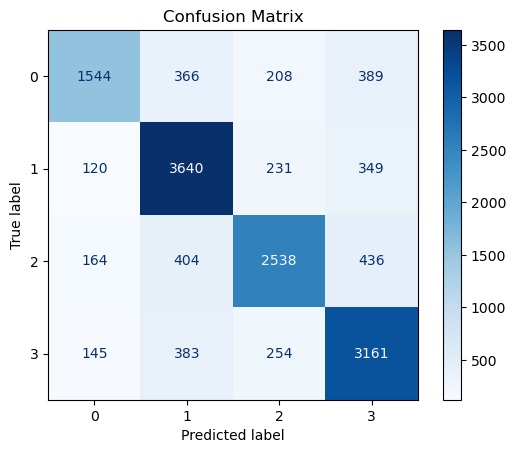

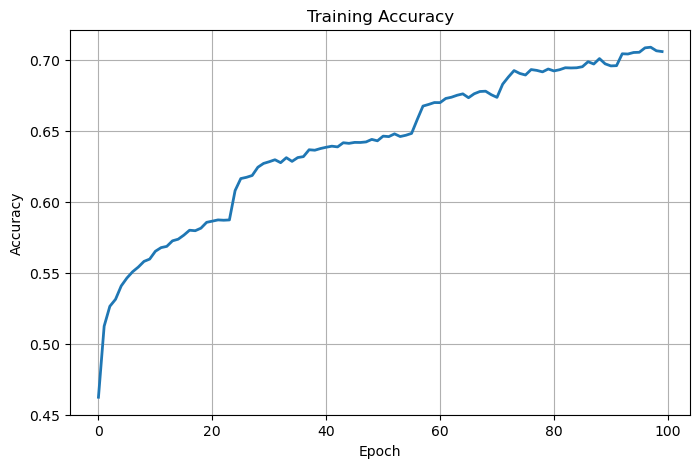

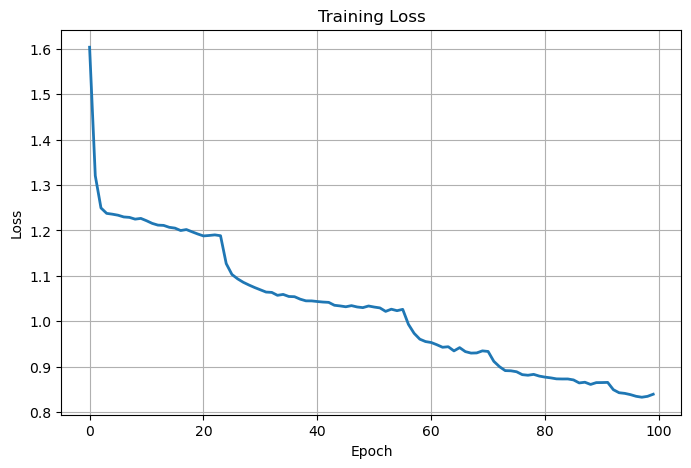


Model Saved Successfully!


In [33]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================================
# Best Parameters
# ==========================================================

best = {
    'learning_rate': 0.009415244195298792,
    'optimizer': 'Adam',
    'activation': 'relu',
    'batch_size': 128,
    'n_layers': 3,
    'units_0': 256,
    'dropout_0': 0.4819038198762265,
    'reg_0': 3.276616214882557e-06,
    'units_1': 256,
    'dropout_1': 0.3258921610124521,
    'reg_1': 2.004525492982464e-05,
    'units_2': 512,
    'dropout_2': 0.25417429799364333,
    'reg_2': 2.6570895590079712e-05
}

# ==========================================================
# Merge Train + Validation
# ==========================================================

X_full = np.vstack((X_train, X_val))
y_full = np.concatenate((y_train, y_val))

print("Training Shape :", X_full.shape)
print("Labels Shape   :", y_full.shape)

# ==========================================================
# Build Model
# ==========================================================

model = Sequential()

model.add(Input(shape=(X_full.shape[1],)))

for i in range(best["n_layers"]):

    model.add(
        Dense(
            units=best[f'units_{i}'],
            activation=best["activation"],
            kernel_regularizer=l1_l2(
                l1=best[f'reg_{i}'],
                l2=best[f'reg_{i}']
            )
        )
    )
    model.add(BatchNormalization())
    model.add(Dropout(best[f'dropout_{i}']))

model.add(Dense(4, activation='softmax'))

# ==========================================================
# Compile
# ==========================================================

optimizer = Adam(
    learning_rate=best["learning_rate"]
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# Callbacks
# ==========================================================

early_stop = EarlyStopping(
    monitor='accuracy',
    patience=8,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ==========================================================
# Train
# ==========================================================

history = model.fit(
    X_full,
    y_full,
    epochs=100,
    batch_size=best["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================================
# Evaluate
# ==========================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Loss     :", round(loss,4))
print("Test Accuracy :", round(accuracy,4))
# ==========================================================
# Predictions
# ==========================================================

y_prob = model.predict(X_test, verbose=0)

y_pred = np.argmax(y_prob, axis=1)

# ==========================================================
# Accuracy
# ==========================================================

print("\nAccuracy Score")

print(accuracy_score(y_test, y_pred))

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report\n")

# Automatically create class names
class_names = [str(i) for i in sorted(np.unique(y_test))]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# Training Accuracy
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    linewidth=2
)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

# ==========================================================
# Training Loss
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    linewidth=2
)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ==========================================================
# Save Model
# ==========================================================

model.save("sentiment_model.keras")

print("\nModel Saved Successfully!")